In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    # nn.Conv2d(30, 30, 1),   # pointwise conv
    # nn.BatchNorm2d(30),
    # nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.MaxPool2d(2),          # 32 → 16
    nn.PReLU(),

    # nn.Conv2d(30, 30, 1),   # pointwise conv
    # nn.BatchNorm2d(30),
    # nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 16 → 8
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 3, padding=1, groups=120),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.MaxPool2d(2),          # 8 → 4
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.MaxPool2d(2),          # 4 → 2
    nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model23_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model23_0)
describe(model23_0)

MACs: 5.62 MMac, Params: 54.09 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─MaxPool2d: 3-7               [1, 30, 16, 16]           --
│    │    └─PReLU: 3-8                   [1, 30, 16, 16]           1
│    └─Sequential: 2-2                   [1, 60, 8, 8]             --
│    │    └─Conv2d: 3-9                  [1, 60, 16, 

Loading checkpoint from model_weights/model23_0.pt
Starting
Epoch 1/60: Train loss = 1.0733, Train accuracy = 0.6175, Test loss = 1.0450, Test accuracy = 0.6269
Epoch 2/60: Train loss = 0.9477, Train accuracy = 0.6673, Test loss = 0.9232, Test accuracy = 0.6814
Epoch 3/60: Train loss = 0.8470, Train accuracy = 0.7066, Test loss = 0.8182, Test accuracy = 0.7265
Epoch 4/60: Train loss = 0.8587, Train accuracy = 0.7072, Test loss = 0.8822, Test accuracy = 0.7029
Epoch 5/60: Train loss = 0.7896, Train accuracy = 0.7251, Test loss = 0.8153, Test accuracy = 0.7277
Epoch 6/60: Train loss = 0.7013, Train accuracy = 0.7572, Test loss = 0.7441, Test accuracy = 0.7486
Epoch 7/60: Train loss = 0.6704, Train accuracy = 0.7718, Test loss = 0.7191, Test accuracy = 0.7558
Epoch 8/60: Train loss = 0.7140, Train accuracy = 0.7586, Test loss = 0.7484, Test accuracy = 0.7585
Epoch 9/60: Train loss = 0.5978, Train accuracy = 0.7918, Test loss = 0.6159, Test accuracy = 0.7909
Epoch 10/60: Train loss = 0.566

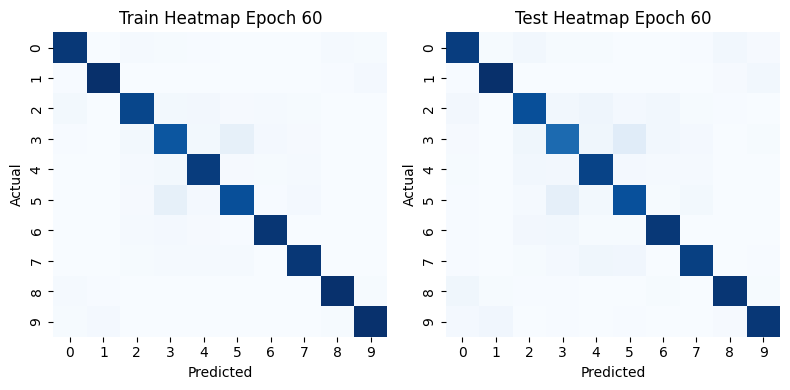

<Figure size 1200x600 with 0 Axes>

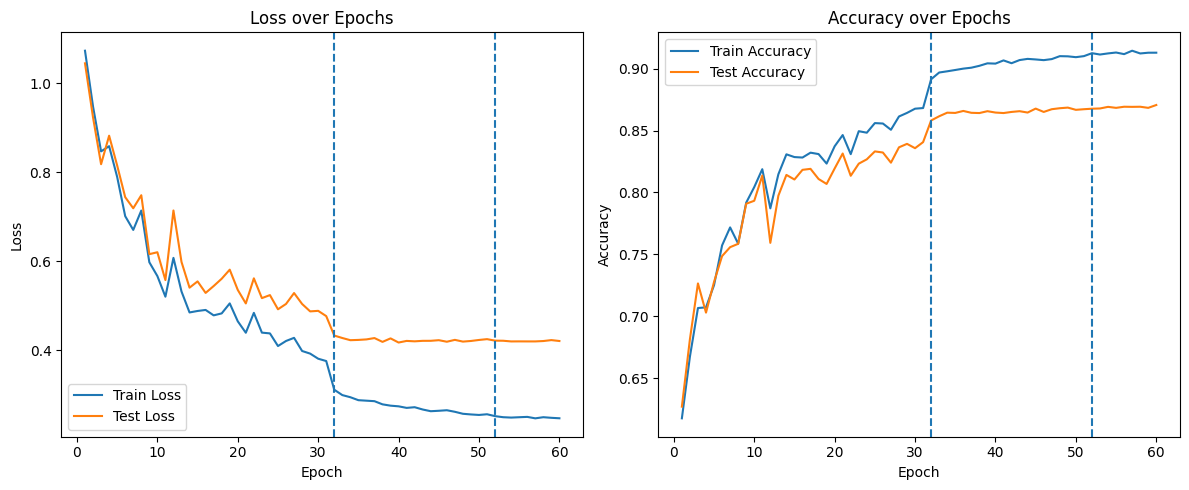

In [6]:
trainf32(model23_0,"model_weights/model23_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model23_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model23_1)
describe(model23_1)

MACs: 5.62 MMac, Params: 54.09 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─MaxPool2d: 3-7               [1, 30, 16, 16]           --
│    │    └─PReLU: 3-8                   [1, 30, 16, 16]           1
│    └─Sequential: 2-2                   [1, 60, 8, 8]             --
│    │    └─Conv2d: 3-9                  [1, 60, 16, 

Loading checkpoint from model_weights/model23_1.pt
Starting
Epoch 1/60: Train loss = 0.9998, Train accuracy = 0.6472, Test loss = 0.9754, Test accuracy = 0.6515
Epoch 2/60: Train loss = 0.8720, Train accuracy = 0.6957, Test loss = 0.8834, Test accuracy = 0.7011
Epoch 3/60: Train loss = 0.7419, Train accuracy = 0.7425, Test loss = 0.7356, Test accuracy = 0.7470
Epoch 4/60: Train loss = 0.6836, Train accuracy = 0.7649, Test loss = 0.7054, Test accuracy = 0.7666
Epoch 5/60: Train loss = 0.6780, Train accuracy = 0.7652, Test loss = 0.7370, Test accuracy = 0.7501
Epoch 6/60: Train loss = 0.6034, Train accuracy = 0.7894, Test loss = 0.6329, Test accuracy = 0.7846
Epoch 7/60: Train loss = 0.6198, Train accuracy = 0.7830, Test loss = 0.6871, Test accuracy = 0.7735
Epoch 8/60: Train loss = 0.5716, Train accuracy = 0.7976, Test loss = 0.6096, Test accuracy = 0.7884
Epoch 9/60: Train loss = 0.5787, Train accuracy = 0.7974, Test loss = 0.6334, Test accuracy = 0.7878
Epoch 10/60: Train loss = 0.552

/home/saptak/.local/lib/python3.14/site-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch 17/60: Train loss = 0.4504, Train accuracy = 0.8442, Test loss = 0.5158, Test accuracy = 0.8287
Epoch 18/60: Train loss = 0.4581, Train accuracy = 0.8433, Test loss = 0.5449, Test accuracy = 0.8208
Epoch 19/60: Train loss = 0.4415, Train accuracy = 0.8449, Test loss = 0.5202, Test accuracy = 0.8252
Epoch 20/60: Train loss = 0.4355, Train accuracy = 0.8499, Test loss = 0.5026, Test accuracy = 0.8283
Epoch 21/60: Train loss = 0.4289, Train accuracy = 0.8490, Test loss = 0.5047, Test accuracy = 0.8322
Epoch 22/60: Train loss = 0.4212, Train accuracy = 0.8545, Test loss = 0.4968, Test accuracy = 0.8378
Epoch 23/60: Train loss = 0.4030, Train accuracy = 0.8608, Test loss = 0.4921, Test accuracy = 0.8346
Epoch 24/60: Train loss = 0.3955, Train accuracy = 0.8616, Test loss = 0.4872, Test accuracy = 0.8347
Epoch 25/60: Train loss = 0.3923, Train accuracy = 0.8622, Test loss = 0.4936, Test accuracy = 0.8334
Epoch 26/60: Train loss = 0.4086, Train accuracy = 0.8585, Test loss = 0.4960, Tes

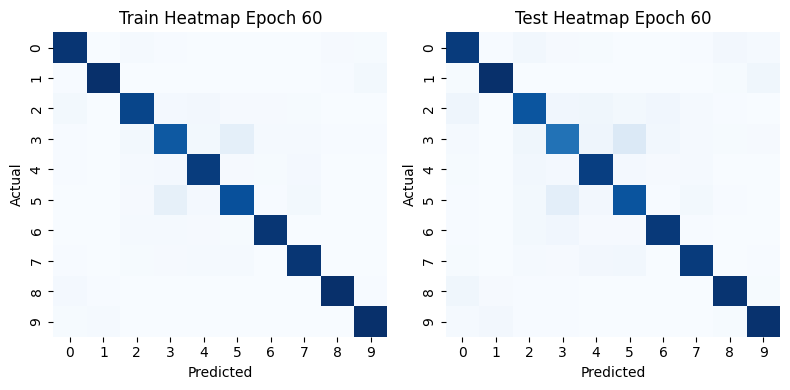

<Figure size 1200x600 with 0 Axes>

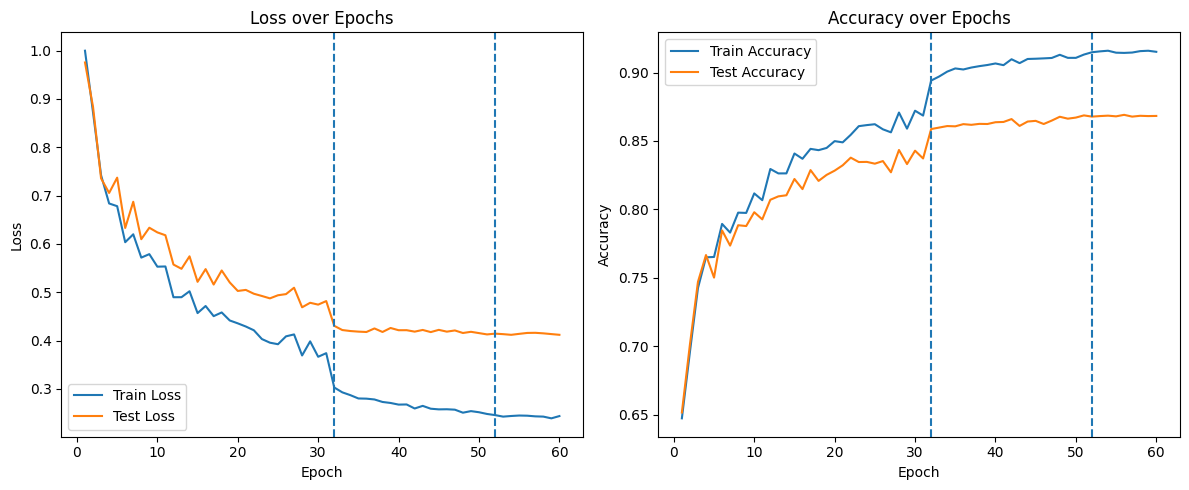

In [8]:
trainf32(model23_1,"model_weights/model23_1.pt",criterion,train_dataset,val_dataset, batch_size=64)